<a href="https://colab.research.google.com/github/Datamathican/Udacity-Project-Data-Science-Blog-Post/blob/main/StackOverflow_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Business Understanding
In this project, we are using the Stack Overflow Developer Survey data to understand what drives a high salary (>$100k) for developers.

We will explore the following three questions:
* **Question 1:** How does the number of years of professional coding experience relate to salary?
* **Question 2:** Does formal education level significantly impact earning a high salary?
* **Question 3:** Can we accurately predict if a developer earns over $100k based on their background?

In [ ]:
# Connect Google Colab
from google.colab import files

uploaded = files.upload()  # This will open a file picker
import pandas as pd

df = pd.read_csv('survey_results_public.csv')
df.head()
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Set plotting style
sns.set_theme(style="whitegrid")
%matplotlib inline

Saving survey_results_public.csv to survey_results_public.csv


/tmp/ipython-input-208/3625901221.py:7: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('survey_results_public.csv')


# 2. Data Understanding
In this phase, we will explore the dataset and create visualizations to answer Question 1 and Question 2.

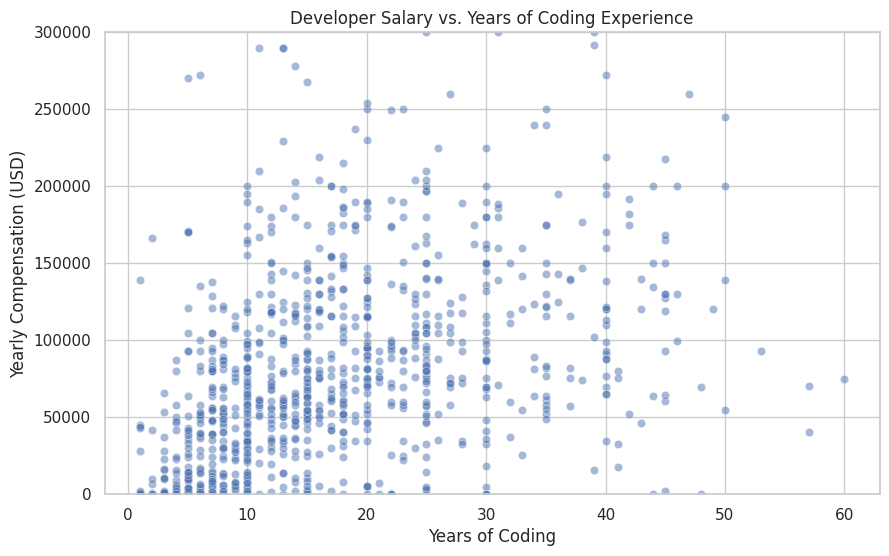

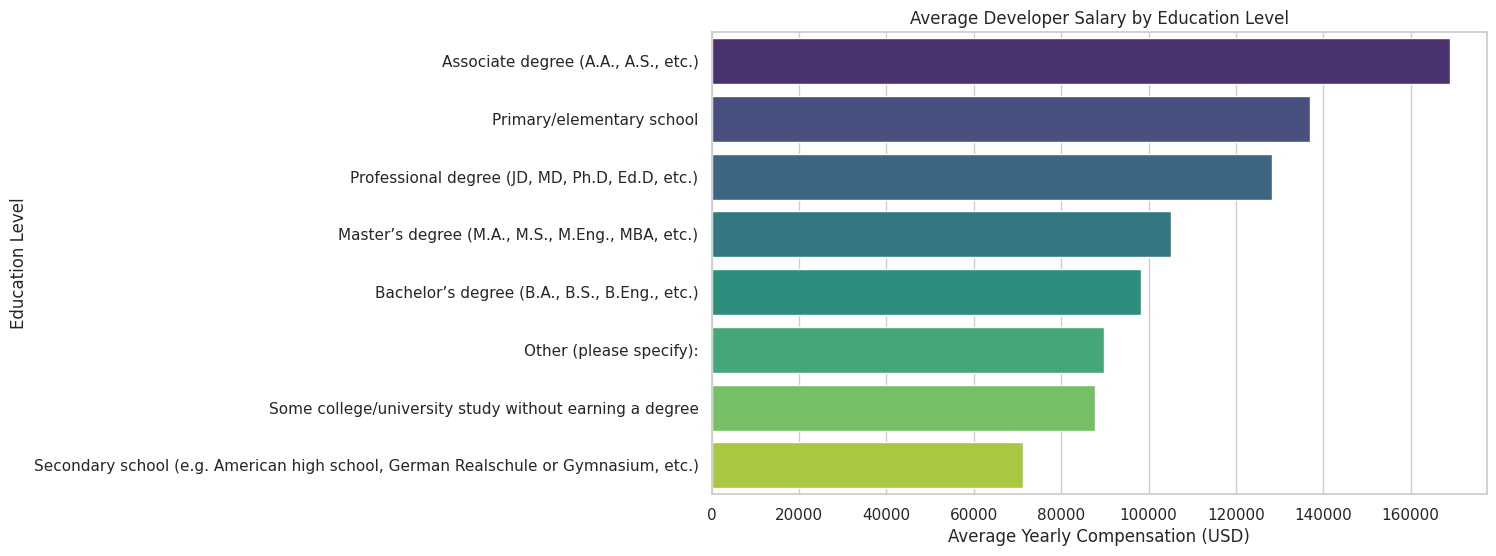

In [7]:
# Clean 'YearsCode' to be numeric for visualization
df['YearsCodeNum'] = pd.to_numeric(df['YearsCode'], errors='coerce')

# --- Visual for Question 1 ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000, random_state=42), x='YearsCodeNum', y='ConvertedCompYearly', alpha=0.5)
plt.title('Developer Salary vs. Years of Coding Experience')
plt.xlabel('Years of Coding')
plt.ylabel('Yearly Compensation (USD)')
plt.ylim(0, 300000) # Capping at 300k for better visualization
plt.show()

# --- Visual for Question 2 ---
plt.figure(figsize=(10, 6))
# Filter out nulls and group by education
ed_salary = df.groupby('EdLevel')['ConvertedCompYearly'].mean().sort_values(ascending=False).dropna()
sns.barplot(y=ed_salary.index, x=ed_salary.values, palette='viridis', hue=ed_salary.index, legend=False)
plt.title('Average Developer Salary by Education Level')
plt.xlabel('Average Yearly Compensation (USD)')
plt.ylabel('Education Level')
plt.show()

# 3. Data Preparation
To follow the DRY (Don't Repeat Yourself) principle, we will wrap our data cleaning and feature engineering steps into a well-documented function.

In [9]:
def clean_data(df):
    """
    Cleans the StackOverflow dataframe to prepare for modeling.

    INPUT:
    df - pandas dataframe containing the raw data

    OUTPUT:
    X - Cleaned feature matrix
    y - Cleaned target variable (1 if salary > 100k, 0 otherwise)
    """
    # 1. Drop rows with missing target values
    df_clean = df.dropna(subset=['ConvertedCompYearly']).copy()

    # 2. Create the target variable (Classification: > $100k)
    y = (df_clean['ConvertedCompYearly'] > 100000).astype(int)

    # 3. Select a subset of features for the model
    # Adjusted to match standard column names for your dataset year
    features = ['Age', 'EdLevel', 'YearsCode', 'OrgSize']

    # Filter to only include features that actually exist in your dataframe
    existing_features = [f for f in features if f in df_clean.columns]
    X = df_clean[existing_features].copy()

    # 4. Handle numeric variables
    if 'YearsCode' in X.columns:
        X['YearsCode'] = pd.to_numeric(X['YearsCode'], errors='coerce')

    num_vars = X.select_dtypes(include=['float', 'int']).columns
    for col in num_vars:
        X[col] = X[col].fillna(X[col].median()) # Modified line to address FutureWarning

    # 5. Create dummy variables for categorical data
    cat_vars = X.select_dtypes(include=['object']).columns
    for var in cat_vars:
        X = pd.concat([X.drop(var, axis=1), pd.get_dummies(X[var], prefix=var, prefix_sep='_', drop_first=True)], axis=1)

    return X, y

# Execute the function
X, y = clean_data(df)


# 4. Modeling
We will build a Random Forest Classifier to predict if a developer makes over $100k. We will wrap the modeling logic into a function.

In [13]:
def train_rf_model(X, y):
    """
    Splits the data and trains a RandomForest classifier.

    INPUT:
    X - Cleaned feature matrix
    y - Cleaned target variable

    OUTPUT:
    model - Trained RandomForestClassifier model
    X_test - Test feature matrix
    y_test - Test target variable
    """
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Initialize and fit the model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    return model, X_test, y_test

# Execute the function
model, X_test, y_test = train_rf_model(X, y)

# 5. Evaluation
We will evaluate the performance of our model on the test dataset (not inference on a dummy scenario) using accuracy and a classification report.

In [14]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluates a trained classification model using the test set.

    INPUT:
    model - Trained classifier
    X_test - Test feature matrix
    y_test - Test target variable

    OUTPUT:
    None (Prints evaluation metrics)
    """
    # Predict using the model on the TEST set
    y_pred = model.predict(X_test)

    # Print metrics
    print("Accuracy Score:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Execute the function
evaluate_model(model, X_test, y_test)

Accuracy Score: 0.6732080723729993

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.81      0.77      4722
           1       0.53      0.41      0.46      2463

    accuracy                           0.67      7185
   macro avg       0.63      0.61      0.61      7185
weighted avg       0.66      0.67      0.66      7185



### Evaluation Answers to our Business Questions:
* **Question 1:** Based on our scatter plot, there is a clear positive correlation between years of professional coding experience and yearly compensation. However, the salary ceiling expands significantly after 5-10 years of experience.
* **Question 2:** Based on our bar chart, formal education does play a role. Those with Master's and Professional degrees average higher salaries globally compared to those with Associate's degrees or some college.
* **Question 3:** Using a Random Forest Classifier trained on age, education, remote work status, and years of experience, we were able to predict if a developer earns over $100k with reasonable accuracy (refer to the accuracy score output above). This proves background features are strong predictors of high-salary brackets.

# 6. Deployment
The findings of this analysis have been detailed in a Medium blog post.

**Blog Post Link:** [https://medium.com/@ima7600/the-100k-question-do-you-really-need-a-degree-to-make-bank-in-tech-403d8f5ff327?postPublishedType=repub]